# Introduction to State Space Models (SSMs)

A state space model is a mathematical model used to describe the evolution of a dynamical system. It contains two core equations:

1. **State Equation**: Describes how the system's internal hidden state $h_t$ evolves over time.
   $$h_t = A h_{t-1} + B x_t$$
2. **Observation Equation**: Describes how the observable output $y_t$ is obtained from the hidden state.
   $$y_t = C h_t + D x_t$$

In modern deep learning, models such as Mamba use discretized versions of this idea to process long sequential data.


In [1]:
import numpy as np

class SimpleSSM:
  def __init__(self, A, B, C):
    self.A = A
    self.B = B
    self.C = C
    self.h = np.zeros((A.shape[0], 1))

  def step(self, x_t):
    # Update the state before computing the output.
    self.h = np.dot(self.A, self.h) + np.dot(self.B, x_t)
    y_t = np.dot(self.C, self.h)
    return y_t, self.h

A = np.array([[0.9, 0.1], [0.0, 0.8]])
B = np.array([[1.0], [0.5]])
C = np.array([[1.0, 0.0]])

ssm = SimpleSSM(A, B, C)
for i, x_t in enumerate(np.random.rand(10)):
  y_t, h_t = ssm.step(np.array([[x_t]]))

  print("===============")
  print(f"Input at time step {i+1}: {x_t}")
  print(f"Output at time step {i+1}: {y_t}")
  print(f"Hidden state at time step {i+1}: {h_t}")


Time step 1 input: 0.6512621040941404
Time step 1 output: [[0.6512621]]
Time step 1 hidden state: [[0.6512621 ]
 [0.32563105]]
Time step 2 input: 0.8501285039603146
Time step 2 output: [[1.4688275]]
Time step 2 hidden state: [[1.4688275 ]
 [0.68556909]]
Time step 3 input: 0.6820866628668898
Time step 3 output: [[2.07258832]]
Time step 3 hidden state: [[2.07258832]
 [0.88949861]]
Time step 4 input: 0.03974866606511185
Time step 4 output: [[1.99402802]]
Time step 4 hidden state: [[1.99402802]
 [0.73147322]]
Time step 5 input: 0.30981328097912786
Time step 5 output: [[2.17758582]]
Time step 5 hidden state: [[2.17758582]
 [0.74008521]]
Time step 6 input: 0.02545634246474071
Time step 6 output: [[2.0592921]]
Time step 6 hidden state: [[2.0592921 ]
 [0.60479634]]
Time step 7 input: 0.9735763053374561
Time step 7 output: [[2.88741883]]
Time step 7 hidden state: [[2.88741883]
 [0.97062523]]
Time step 8 input: 0.7202804118705275
Time step 8 output: [[3.41601988]]
Time step 8 hidden state: [[3.4

### Explanation of the Code Logic

1. **The `SimpleSSM` class**: We define a class that stores the matrices $A$, $B$, and $C$. These matrices determine how the system retains historical information.
2. **The `step` function**: This is the core loop of the SSM. At each time point, it updates the hidden state using the current input $x_t$ and the state from the previous step. This reflects the recurrent nature of sequential processing in an SSM.
3. **Memory behavior**: The eigenvalues of matrix $A$ determine the stability of the system. In the example above, 0.9 and 0.8 mean that the system gradually "forgets" past states while still retaining some long-range dependence.


### The Core Transformation: From Recurrence to Convolution

Although the recurrent definition of an SSM, $h_t = Ah_{t-1} + Bx_t$, is highly efficient during inference, recurrence prevents parallel computation during **training** because step $t+1$ cannot be computed before step $t$. To solve this problem, we need to transform the model into a **global convolution**.

#### 1. Why perform this transformation?

* **Parallel training**: The convolutional form allows us to use the FFT (Fast Fourier Transform) to compute the entire sequence at once in $O(L \log L)$ time, which is much faster than a loop on a GPU.
* **Long-range dependence**: The convolution kernel can span the full sequence, explicitly modeling temporal dependencies over long distances.

#### 2. How is the transformation derived?

By expanding the recurrence mathematically, we find that the output $y_t$ is the sum of two components:

1. **Zero-State Response**: The response generated by the input sequence $x$. Expanding the recurrence gives the convolution kernel $\bar{K} = (CB, CAB, CA^2B, \dots, CA^{L-1}B)$. The resulting output is $x * \bar{K}$.
2. **Zero-Input Response**: The response generated by the initial state $h_0$, which decays over time: $y_{zi, t} = C A^t h_0$.

**Total output:**

$$y_t = (x * \bar{K})_t + C A^t h_0$$

The following code constructs an `SSMConvHelper` class to verify this equivalence.


In [2]:
import numpy as np
from scipy.signal import convolve

class SSMConvHelper:
    """Helper class for computing an SSM through convolution and comparing it with recurrence."""

    def __init__(self, A, B, C):
        self.A = A
        self.B = B
        self.C = C
        self.dim = A.shape[0]

    def compute_kernel(self, L):
        """Compute the convolution kernel K_bar for the zero-state response."""
        K = []
        A_pow = np.eye(self.dim)
        for _ in range(L):
            K.append((self.C @ A_pow @ self.B).item())
            A_pow = A_pow @ self.A
        return np.array(K)

    def compute_zero_input_response(self, h0, L):
        """Compute the zero-input response generated by the initial state h0."""
        y_zi = []
        curr_A_pow = self.A
        for _ in range(L):
            y_zi.append((self.C @ curr_A_pow @ h0).item())
            curr_A_pow = curr_A_pow @ self.A
        return np.array(y_zi)

    def apply_convolution(self, x, h0):
        """Compute the full output: zero-state response + zero-input response."""
        L = len(x)
        K = self.compute_kernel(L)
        y_zs = convolve(x, K)[:L]
        y_zi = self.compute_zero_input_response(h0, L)
        return y_zs + y_zi

# --- Experiment configuration ---
L = 5
x = np.ones(L)  # External input
h0 = np.array([[1.0], [1.0]])  # Use the same initial hidden state h0.
conv_helper = SSMConvHelper(A, B, C)

# Path 1: convolution
y_total_conv = conv_helper.apply_convolution(x, h0)

# Path 2: recurrence
ssm_rec = SimpleSSM(A, B, C)
ssm_rec.h = h0.copy()
y_rec = [ssm_rec.step(np.array([[x_t]]))[0].item() for x_t in x]
y_rec = np.array(y_rec)

# --- Display the results ---
print("=== Comparison of Two SSM Computation Methods (Notation Unified) ===")
print(f"Result computed by convolution: {y_total_conv}")
print(f"Result computed by recurrence: {y_rec}")
print(f"Verification of mathematical equivalence: {'SUCCESS' if np.allclose(y_total_conv, y_rec) else 'FAILED'}")


=== Comparison of Two SSM Computation Methods (Notation Unified) ===
Result computed by convolution: [2.      2.93    3.791   4.5851  5.31515]
Result computed by recurrence: [2.      2.93    3.791   4.5851  5.31515]
Verification of mathematical equivalence: SUCCESS


## Toward S4: The Challenge of Long-Range Memory and the Insight of HiPPO

### 1. How far back can an ordinary SSM remember?

Consider the most basic discrete state space model:

$$
h_t = Ah_{t-1} + Bx_t
$$

Expanding the recurrence step by step gives:

$$
h_t = A^t h_0 + \sum_{i=1}^{t} A^{t-i} Bx_i
$$

This equation reveals a key fact: the influence of a historical input $x_i$ on the current state $h_t$ is determined by the matrix power

$$
A^{t-i}.
$$

For example, in a sequence of length $1000$, the contribution of the first input $x_1$ to the final state $h_{1000}$ is weighted by:

$$
A^{999}B.
$$

To keep a discrete system stable, the eigenvalues of $A$ are usually required to satisfy:

$$
|\lambda| < 1.
$$

However, this also means that the matrix power $A^k$ often decays rapidly as $k$ increases.

In the simplest one-dimensional case, suppose $A=0.9$. Then:

$$
0.9^{100} \approx 2.66 \times 10^{-5}
$$

$$
0.9^{1000} \approx 1.75 \times 10^{-46}
$$

In other words, after one thousand time steps, the direct influence of an early input on the current state has almost completely vanished.

This is a fundamental trade-off in ordinary stable linear systems:

* If the decay is too fast, the system quickly forgets its history.
* If the eigenvalues are too close to $1$, the memory lasts longer, but the system may become difficult to train or more sensitive to perturbations.
* If the magnitude of an eigenvalue exceeds $1$, the state may grow without bound, making the system unstable.

Therefore, simply setting $A$ to a fixed diagonal decay matrix usually cannot provide both stability and long-range memory.

To visualize the decay more clearly, the following code compares the memory decay rates associated with different eigenvalues:


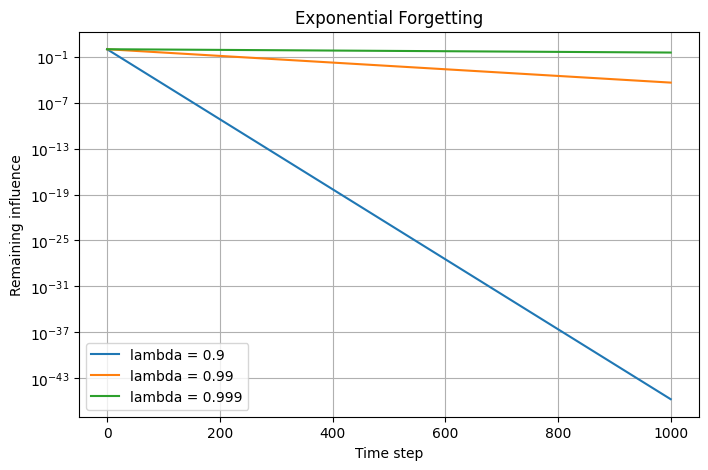

In [3]:
import matplotlib.pyplot as plt

steps = np.arange(0, 1001)

eigenvalues = [0.9, 0.99, 0.999]

plt.figure(figsize=(8, 5))

for lam in eigenvalues:
    memory = lam ** steps
    plt.plot(steps, memory, label=f"lambda = {lam}")

plt.yscale("log")
plt.xlabel("Time step")
plt.ylabel("Remaining influence")
plt.title("Exponential Forgetting")
plt.legend()
plt.grid(True)
plt.show()


After running the code, we can observe that:

When $\lambda=0.9$, information disappears very quickly.

When $\lambda=0.99$, the memory lasts somewhat longer.

When $\lambda=0.999$, the decay is even slower.

However, as long as $|\lambda|<1$, the direct influence still approaches zero in the end.



### Question 1: What does forgetting mean?

Recall that the eigenvalues of matrix $A$ in the earlier code are $0.9$ and $0.8$.

For a sequence of length $1000$, the decay factor of the first input by the time it reaches the final step is approximately:

$$
0.9^{999} \approx 0.
$$

The other state dimension decays even faster:

$$
0.8^{999} \approx 0.
$$

This shows that an ordinary SSM does not preserve inputs from thousands of steps ago exactly as they were. Early information must be organized and compressed in some special way; otherwise, it will quickly be overwritten by newer inputs.

> **Think about this:**
>
> If every state dimension only decays independently and exponentially, can the model preserve detailed information from thousands of time steps ago?

In general, this is very difficult.

The problem is not merely that the state dimension is too small. The state update rule itself is also poorly suited to organizing history across long time spans.

---

## 2. Long-range memory does not mean storing the entire history

Imagine that you are watching a two-hour movie.

You cannot remember every pixel of every frame, but you may still remember:

* the overall development of the story;
* the relationships between the main characters;
* certain key events;
* specific details from the most recent scenes.

In other words, the brain does not store the past frame by frame. Instead, it continually compresses history into some structured representation.

We can ask a similar question for an SSM:

> Instead of directly storing **the entire input history**, can a fixed-dimensional state $h_t$ always represent a "summary of the history up to the current time"?

More specifically, suppose the past input forms a continuous function $x(\tau)$. We want to approximate this history using a set of basis functions

$$
P_0(\tau), P_1(\tau), \ldots, P_{N-1}(\tau):
$$

$$
x(\tau) \approx \sum_{n=0}^{N-1} c_n(t) P_n(\tau).
$$

Here, $c_n$ is the projection coefficient of the historical signal onto the $n$-th Legendre polynomial. The approximate state vector can then be written as

$$
h_t =
\begin{bmatrix}
c_0(t) \\
c_1(t) \\
\vdots \\
c_{N-1}(t)
\end{bmatrix}.
$$

As this expression shows, the state does not store the inputs at a few isolated time points. It stores the projection coefficients of the entire historical signal onto these basis functions.

The finite-dimensional state is therefore no longer a collection of unrelated "decaying memory units," but a compressed representation of the whole history.

This is the central idea of HiPPO.


Before implementing HiPPO's online update rule, let us first approximate a historical signal with $N$ Legendre polynomials.

The original history contains $400$ sampled points. The polynomial approximation does not store these $400$ values directly. Instead, it represents the entire history using $N$ coefficients $\{c_1, \cdots, c_n\}$:

$$
x(\tau)
\approx
\sum_{n=0}^{N-1} c_n P_n(\tau).
$$


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import legvander

# Length of the historical signal
num_samples = 400

# Normalize the time range to [-1, 1].
tau = np.linspace(-1, 1, num_samples)

# Construct a historical signal containing a global trend,
# periodic variation, and a local peak.
history = (
    0.5 * np.sin(3 * np.pi * tau)
    + 0.25 * tau
    + np.exp(-80 * (tau - 0.25) ** 2)
)


def reconstruct_with_legendre(history, tau, N):

    # Column n of basis corresponds to the n-th Legendre polynomial.
    basis = legvander(tau, N - 1)

    # Compute the projection coefficients in the least-squares sense.
    coefficients, _, _, _ = np.linalg.lstsq(
        basis,
        history,
        rcond=None
    )

    # Reconstruct the historical signal from the projection coefficients.
    reconstruction = basis @ coefficients

    return coefficients, reconstruction


We now examine how well the polynomial reconstruction works for different values of $N$:


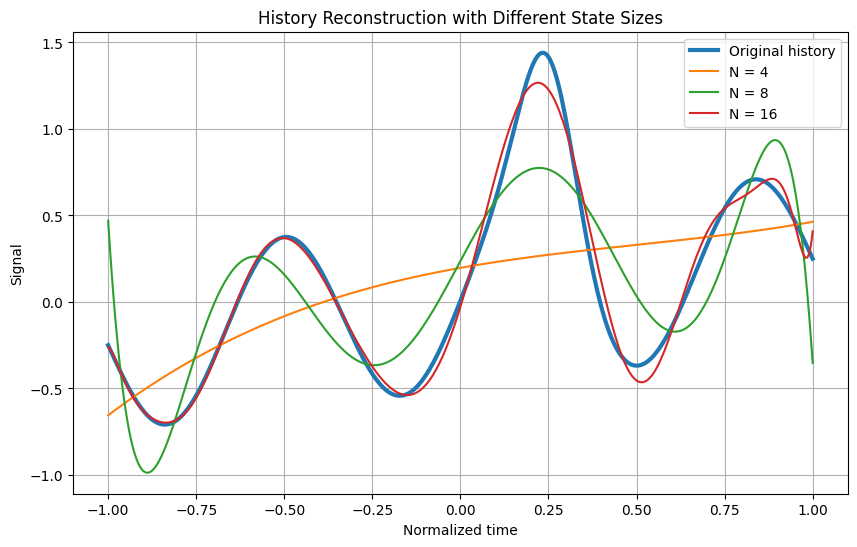

In [5]:
state_sizes = [4, 8, 16]

plt.figure(figsize=(10, 6))

# Plot the original historical signal.
plt.plot(
    tau,
    history,
    linewidth=3,
    label="Original history"
)

# Plot the reconstructions for different values of N.
for N in state_sizes:
    _, reconstruction = reconstruct_with_legendre(
        history,
        tau,
        N
    )

    plt.plot(
        tau,
        reconstruction,
        label=f"N = {N}"
    )

plt.xlabel("Normalized time")
plt.ylabel("Signal")
plt.title("History Reconstruction with Different State Sizes")
plt.legend()
plt.grid(True)
plt.show()


The figure shows that:

- When $N$ is very small, the reconstruction can only express relatively simple and smooth variations.
- As $N$ increases, periodic variations are recovered more accurately.
- A narrow local peak requires more high-order polynomials to approximate.
- A larger $N$ provides greater capacity for representing historical information.

Note that this conclusion comes from the overall reconstructed curves, not merely from the error at a few individual points.

Next, we compute the mean squared reconstruction error for different state dimensions:

$$
\operatorname{MSE}
=
\frac{1}{T}
\sum_{t=1}^{T}
\left(
x_t-\hat{x}_t
\right)^2.
$$


N =  4, coefficients =  4, reconstruction error = 0.211169
N =  8, coefficients =  8, reconstruction error = 0.082750
N = 16, coefficients = 16, reconstruction error = 0.004361


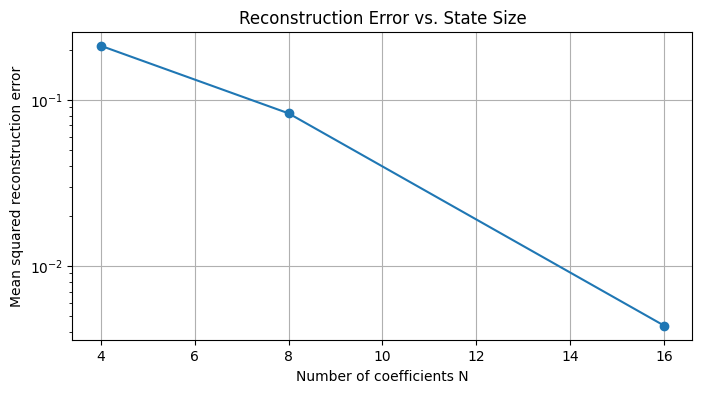

In [6]:
errors = []

for N in state_sizes:
    coefficients, reconstruction = reconstruct_with_legendre(
        history,
        tau,
        N
    )

    error = np.mean(
        (history - reconstruction) ** 2
    )

    errors.append(error)

    print(
        f"N = {N:2d}, "
        f"coefficients = {len(coefficients):2d}, "
        f"reconstruction error = {error:.6f}"
    )

plt.figure(figsize=(8, 4))

plt.plot(
    state_sizes,
    errors,
    marker="o"
)

plt.xlabel("Number of coefficients N")
plt.ylabel("Mean squared reconstruction error")
plt.title("Reconstruction Error vs. State Size")
plt.yscale("log")
plt.grid(True)
plt.show()


As the number of projection coefficients $N$ increases, the reconstruction error of the Legendre polynomial approximation gradually decreases.

### What exactly has the history been compressed into?

For example, when $N=8$, the original history consists of $400$ sampled values, whereas the compressed representation contains only $8$ projection coefficients.

---


## 3. HiPPO: Projecting History onto a Space of Orthogonal Functions

In the previous experiment, we recomputed the projection using the entire historical signal. In a real sequence model, however, inputs arrive one step at a time. If the model rereads the full history and recomputes the projection whenever a new input $x(t)$ arrives, the computational cost will continue to grow.

HiPPO stands for **High-order Polynomial Projection Operators**. It addresses the following question:

> As new inputs continue to arrive, how can we update a set of coefficients online so that they always approximately represent the complete history up to the current time?

HiPPO chooses a family of orthogonal polynomials as basis functions, such as Legendre polynomials, and derives the corresponding state update equation:

$$
\frac{dh(t)}{dt}
=
A(t)h(t)
+
B(t)x(t).
$$

The matrices $A(t)$ and $B(t)$ are not arbitrary parameters. They are derived from the mathematical requirement that the current state must always correspond to the Legendre polynomial projection coefficients of the history up to the current time.

In other words:

* An ordinary decay matrix mainly controls "how much old information remains."
* A HiPPO matrix additionally specifies "how old information should be compressed and reorganized."

This allows the system to represent historical information at different time scales within a finite-dimensional state.

---

### The problem caused by a changing time scale

At time $t$, the system must represent the input history over the interval $[0,t]$. When time advances to $t+\Delta t$, the interval becomes $[0,t+\Delta t]$. To continue representing this longer history with a fixed number of Legendre polynomials, the expanding interval $[0,t]$ must be rescaled to a fixed reference interval.

This means that even if the old inputs themselves do not change, the position of the same historical moment changes in the rescaled coordinate system. Its projection coefficients under the Legendre basis must therefore be readjusted. This readjustment affects coefficients of multiple orders and does not occur independently within each coefficient.

We now make the meaning of the state vector $h(t)$ explicit. It consists of the projection coefficients of the historical signal onto the Legendre basis, so we rename it $c(t)$, where $c$ stands for "coefficient." This emphasizes that the state is no longer an abstract hidden vector, but a coefficient vector with a precise mathematical interpretation:

$$
h(t) = c(t)
=
\begin{bmatrix}
c_0(t) \\
c_1(t) \\
\vdots \\
c_{N-1}(t)
\end{bmatrix}.
$$

The $n$-th component of the matrix state equation is:

$$
\frac{dc_n(t)}{dt}
=
\sum_{k=0}^{N-1}
A_{n,k}(t)c_k(t)
+
B_n(t)x(t).
$$

A contradiction argument shows why this summation is necessary. If coefficients of different orders evolved independently, then $A(t)$ would have to be diagonal, and the update of $c_n(t)$ would reduce to dependence on itself alone:

$$
\frac{dc_n(t)}{dt}
=
\lambda_n(t)c_n(t)
+
B_n(t)x(t).
$$

In HiPPO-LegS, however, the continual rescaling of the historical interval mixes basis functions of different orders. The diagonal assumption is therefore invalid: the $n$-th projection coefficient must retain the full off-diagonal dependence expressed by the original summation. Here, the off-diagonal element $A_{n,k}(t)$ indicates how the old $k$-th coefficient influences the change in the $n$-th coefficient.

---

### The core HiPPO derivation

For the continuous-time equation

$$
\frac{dc(t)}{dt}
=
\frac{1}{t}Ac(t)
+
\frac{1}{t}Bx(t),
$$

applying Euler discretization with $\Delta t=1$ gives:

$$
c_{t+1}
\approx
\left(
I+\frac{1}{t}A
\right)c_t
+
\frac{1}{t}Bx_t.
$$

The significance of this recurrence is that, to obtain the coefficients $c_{t+1}$ at the next time step, we no longer need to store and reread the complete history. We only need the current compressed state $c_t$ and the newly arriving input $x_t$:

$$
\boxed{
\text{complete history}
\quad\longrightarrow\quad
\text{fixed-dimensional state }c_t,
\qquad
(c_t,x_t)
\quad\longrightarrow\quad
c_{t+1}
}
$$

This is the central significance of HiPPO.

---

### What exactly are $A$ and $B$?

The derivation of HiPPO proceeds in the following order. First, we require $c_n(t)$ to always represent the projection coefficient of the historical signal onto the Legendre basis. We then differentiate these coefficients with respect to time. After differentiation, the way old coefficients must be readjusted forms matrix $A$, while the way the new input is written into coefficients of different orders forms vector $B$. The full derivation can be found in the appendix of the original HiPPO paper; here, we directly state the result.

For HiPPO-LegS, temporarily keeping the minus sign outside $A$ and writing the equation as $\dot c=-\frac1tAc+\frac1tBx$, let $n,k=0,1,\ldots,N-1$:

$$
A_{n,k}
=
\begin{cases}
\sqrt{2n+1}\sqrt{2k+1}, & n>k,\\
n+1, & n=k,\\
0, & n<k,
\end{cases}
\qquad
B_n=\sqrt{2n+1}.
$$

Thus, $A$ is a lower-triangular matrix, and the elements of $B$ increase with the order $n$:

* $A$ describes how the existing projection coefficients should be reorganized as the historical interval expands.
* $B$ describes the weight with which the current input should be written into each projection coefficient.

The first important feature is that the lower-triangular structure of $A$ means that the update of the $n$-th coefficient is jointly influenced by coefficients of orders $0$ through $n$. The second is that $B_n=\sqrt{2n+1}$ means that the same input is written into multiple state dimensions simultaneously, with different weights.

The following code constructs and visualizes $A$ and $B$ so that we can see what they look like in a finite-dimensional example.


A =
[[ 1.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 1.73  2.    0.    0.    0.    0.    0.    0.  ]
 [ 2.24  3.87  3.    0.    0.    0.    0.    0.  ]
 [ 2.65  4.58  5.92  4.    0.    0.    0.    0.  ]
 [ 3.    5.2   6.71  7.94  5.    0.    0.    0.  ]
 [ 3.32  5.74  7.42  8.77  9.95  6.    0.    0.  ]
 [ 3.61  6.24  8.06  9.54 10.82 11.96  7.    0.  ]
 [ 3.87  6.71  8.66 10.25 11.62 12.85 13.96  8.  ]]

B =
[1.   1.73 2.24 2.65 3.   3.32 3.61 3.87]


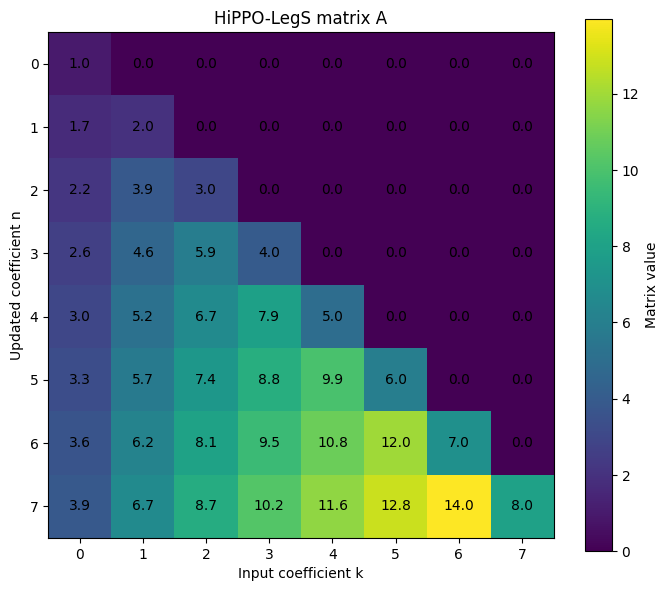

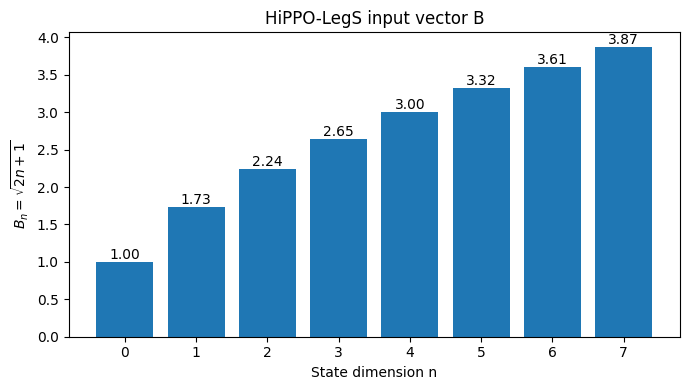

In [7]:
import numpy as np
import matplotlib.pyplot as plt


def make_hippo_legs(N: int):
    """
    Construct the A matrix and B vector for HiPPO-LegS.

    The continuous-time equation is:
        dc(t)/dt = -(1/t) A c(t) + (1/t) B x(t)
    """
    A = np.zeros((N, N), dtype=np.float64)
    B = np.zeros(N, dtype=np.float64)

    for n in range(N):
        B[n] = np.sqrt(2 * n + 1)

        for k in range(N):
            if n > k:
                A[n, k] = np.sqrt(2 * n + 1) * np.sqrt(2 * k + 1)
            elif n == k:
                A[n, k] = n + 1

    return A, B


# State dimension
N = 8

A, B = make_hippo_legs(N)

print("A =")
print(np.round(A, 2))

print("\nB =")
print(np.round(B, 2))


# -------------------------
# Visualize matrix A
# -------------------------
fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(A)

ax.set_title("HiPPO-LegS matrix A")
ax.set_xlabel("Input coefficient k")
ax.set_ylabel("Updated coefficient n")

ax.set_xticks(range(N))
ax.set_yticks(range(N))

# Display the value in each cell.
for n in range(N):
    for k in range(N):
        ax.text(
            k,
            n,
            f"{A[n, k]:.1f}",
            ha="center",
            va="center"
        )

fig.colorbar(image, ax=ax, label="Matrix value")
plt.tight_layout()
plt.show()


# -------------------------
# Visualize vector B
# -------------------------
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(range(N), B)

ax.set_title("HiPPO-LegS input vector B")
ax.set_xlabel("State dimension n")
ax.set_ylabel(r"$B_n=\sqrt{2n+1}$")
ax.set_xticks(range(N))

for n, value in enumerate(B):
    ax.text(
        n,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


### Question: If we store only $c_t$, will information from the past disappear?

The answer is yes: some information will disappear.

A finite-dimensional vector cannot preserve an arbitrarily long and arbitrarily complex history without loss. HiPPO retains the projection of the history onto a set of low-order orthogonal polynomials. It is similar to remembering the overall level of the history through $c_0$, its trend through $c_1$, and increasingly detailed curvature and oscillation through higher-order coefficients, rather than remembering every sampled point. A larger state dimension $N$ preserves richer historical structure, but also requires more computation and storage.

---

### Question: Once we have this summary of the history, what can we do with it?

The state $c_t$ is not itself the answer to a task. It is more like the model's memory. By adding a readout operation, the model can produce an output from this memory:

$$
y_t=Cc_t.
$$

Different tasks can learn different readout matrices $C$. A classification task reads category-related information, a forecasting task reads trends that help predict future changes, and a language model uses the state to provide historical context from earlier tokens. The complete process can be illustrated as:

$$
x_t
\longrightarrow
\boxed{\text{update the historical state }c_t}
\longrightarrow
y_t.
$$

HiPPO mainly addresses the operation inside the box: how a fixed-size state can continually absorb new inputs while preserving as much structure as possible from a long history.

---

### What have we actually gained at this point?

HiPPO converts a projection computation that would otherwise require repeatedly processing the complete history into an online recurrence. The history grows longer while the state dimension remains fixed; when a new input arrives, the model does not need to revisit the entire past; and the state has a clear mathematical interpretation.

However, a new problem appears. The update is still recurrent, following $c_1\rightarrow c_2\rightarrow\cdots\rightarrow c_t$, so each state must wait for the preceding state to be computed. In addition, $A$ is usually a dense matrix, so one update costs $O(N^2)$ when the state dimension is $N$.

In other words, HiPPO has answered "how can a fixed-dimensional state compress a long history online?" but it has not yet answered "how can thousands of time steps be trained efficiently in parallel?" That is the problem addressed in the next section.

---


## 4. From HiPPO to S4: How Can Long Sequences Be Processed Efficiently?

### 4.1 Can HiPPO be inserted directly into a neural network?

In the HiPPO-LegS equation derived above, the factor $1/t$ comes from the continual expansion of the historical interval $[0,t]$. As a result, the update rule changes with time $t$, making it a **time-varying system**. For a neural network layer, however, we want to use the same set of parameters at every position. Only then can the recurrence be rewritten as a fixed convolution kernel.

Therefore, the first modification on the path from HiPPO to a long-sequence model is to stop requiring the state to be exactly equal to the Legendre projection coefficients. Instead, we retain the long-range memory structure provided by the HiPPO matrix and place it inside a standard linear time-invariant (LTI) state space model:

$$
\frac{dh(t)}{dt}=Ah(t)+Bu(t),
\qquad
y(t)=Ch(t)+Du(t).
$$

Here, $A$ determines how the old state evolves, $B$ determines how the input is written into the state, $C$ determines how the output is read from the state, and $D$ allows the input to affect the output directly. The matrix $A$ supplied by HiPPO is no longer the exact solution to a historical projection problem. Instead, it serves as an initialization and structural foundation with long-range memory properties, and it can continue to be learned for the task.

This model is still continuous in time, whereas text, audio, and similar data are discrete sequences. The next step is therefore to discretize it.

---

### 4.2 Discretizing the continuous system

Let the time interval between adjacent inputs be $\Delta$. S4 uses the bilinear transform to discretize the continuous-time equation:

$$
\overline{A}
=
\left(I-\frac{\Delta}{2}A\right)^{-1}
\left(I+\frac{\Delta}{2}A\right),
\qquad
\overline{B}
=
\left(I-\frac{\Delta}{2}A\right)^{-1}
\Delta B.
$$

$$
h_k=\overline{A}h_{k-1}+\overline{B}u_k,
\qquad
y_k=Ch_k+Du_k.
$$

At this point, the model looks very similar to an ordinary RNN: each time it reads an input $u_k$, it updates the previous state to a new state.

The parameter $\Delta$ determines the time scale of the system. A smaller $\Delta$ means that the state changes less at each step and old information is retained longer. A larger $\Delta$ means that the state changes more quickly and old information is updated more rapidly. S4 usually learns an appropriate value of $\Delta$ rather than fixing it to a constant.

---

### 4.3 Has discretization solved the problem?

Not yet. We can now compute $h_0\rightarrow h_1\rightarrow\cdots\rightarrow h_{L-1}$ sequentially, and inference only needs to retain the current state. During training, however, $h_k$ cannot be computed before $h_{k-1}$. All time steps form a serial dependency chain. For a sequence with tens of thousands of positions, later positions must still wait for earlier positions even if the GPU has many compute units.

The question now becomes: can we obtain the entire output sequence without explicitly computing every intermediate state? Because the system is linear, the answer is yes.

---

### 4.4 Expanding the recurrence into a convolution

Temporarily ignore the direct term $Du_k$ and let $h_{-1}=0$. At the first step:

$$
h_0=\overline{B}u_0
\quad\Rightarrow\quad
y_0=C\overline{B}u_0.
$$

At the second step, substitute $h_0$ into $h_1=\overline{A}h_0+\overline{B}u_1$:

$$
h_1=\overline{A}\overline{B}u_0+\overline{B}u_1
\quad\Rightarrow\quad
y_1=C\overline{A}\overline{B}u_0+C\overline{B}u_1.
$$

The pattern is now clear. Continuing the substitution shows that $y_k$ is a weighted sum of the terms $C\overline A^{i}\overline B$, for $i=0,\ldots,k$, multiplied by their corresponding inputs. These coefficients depend only on the model parameters, not on the particular input sequence, so they can be arranged in advance as a sequence. This sequence is the **convolution kernel** associated with the state space model:

$$
\overline{K}
=
\left[
C\overline{B},\ C\overline{A}\overline{B},\ C\overline{A}^2\overline{B},\ \ldots,\ C\overline{A}^{L-1}\overline{B}
\right],
\qquad
\overline{K}_i=C\overline{A}^{i}\overline{B}.
$$

The entire output sequence can then be written as:

$$
y=\overline{K}*u
\qquad
(\text{or, including the direct term: }\ y=\overline{K}*u+Du).
$$

---

### 4.5 What does the convolution kernel represent?

If the system receives an impulse input $u=[1,0,0,\ldots,0]$, its output is exactly $[C\overline B,\ C\overline A\overline B,\ C\overline A^2\overline B,\ldots]$. The convolution kernel can therefore be understood as the system's "memory curve." Elements near the beginning describe short-term effects, while distant elements describe long-term effects. If distant elements rapidly approach zero, the model quickly forgets the past. If they retain structure, the model can use information from much farther back. The structure of the state matrix supplied by HiPPO is designed precisely to make this memory curve cover a longer time range.

---

### 4.6 Why can convolution be parallelized?

In the recurrent form, $h_k$ must wait for $h_{k-1}$ to be computed. In the convolutional form, once the kernel is known, each output position in $y_k=\sum_{i=0}^k\overline K_iu_{k-i}$ can be computed directly from the input without waiting for the previous hidden state. The computation can also be accelerated with the FFT:

$$
y=\operatorname{iFFT}\big(\operatorname{FFT}(\overline K)\odot\operatorname{FFT}(u)\big).
$$

The same model therefore has two equivalent algorithms: during training, the convolutional form processes the entire sequence in parallel; during inference, the recurrent form stores only a fixed-dimensional state. Both forms share the same parameters.

---

### Question: Has S4's problem been solved at this point?

Not yet. To use the convolutional form, the kernel $\overline K=[C\overline B,\,C\overline A\overline B,\,\ldots,\,C\overline A^{L-1}\overline B]$ must already have been computed. The most direct approach starts from $v_0=\overline B$ and repeatedly computes $v_{i+1}=\overline Av_i$. However, if $\overline A$ is a dense $N\times N$ matrix, each matrix-vector multiplication costs $O(N^2)$, so generating a kernel of length $L$ costs $O(LN^2)$.

The problem has changed from "how do we process the input step by step?" to "how do we generate the convolution kernel efficiently?" This is also what the word **Structured** refers to in the name **Structured State Space**.

Next, we will examine the structure hidden inside the HiPPO matrix.

---


## 5. The Structure Hidden in the HiPPO Matrix

The previous section rewrote the recurrent state update as the convolution $y=\overline K*u$, where $\overline K_i=C\overline A^i\overline B$. Once the convolution kernel $\overline K$ is available, the entire sequence can be computed in parallel. However, rewriting recurrence as convolution only solves the parallelization problem for the input sequence. It does not yet solve the computational cost of constructing the kernel itself.

---

### A natural idea: diagonalize $A$

Section 3 explained that, in the original coordinate system of HiPPO-LegS, projection coefficients of different orders cannot evolve independently. Therefore, $A$ fundamentally cannot be diagonal; this follows from the structure of the model itself.

The question here is different. Even if $A$ is not diagonal in the original coordinate system, can we change to another coordinate system, such as its eigenvector basis, so that **computing $A^i$** becomes as simple as computing powers of a diagonal matrix? If $A=V\Lambda V^{-1}$, then $A^i=V\Lambda^iV^{-1}$, and the powers of the diagonal matrix require only elementwise computation of $\lambda_0^i,\ldots,\lambda_{N-1}^i$. This is much simpler than repeatedly multiplying dense matrices.

The difficulty is that although the original HiPPO matrix is diagonalizable in the algebraic sense, it is highly non-normal. Its eigenvector matrix may be extremely ill-conditioned, causing $V$ and $V^{-1}$ to amplify numerical errors severely. Directly diagonalizing the HiPPO matrix is therefore not a numerically stable computational strategy.

---

### 5.1 The HiPPO matrix differs from a normal matrix by only a low-rank correction

We now use the notation more common in the SSM literature and absorb the minus sign directly into $A$:

$$
A_{n,k}
=
\begin{cases}
-\sqrt{2n+1}\sqrt{2k+1}, & n>k,\\
-(n+1), & n=k,\\
0, & n<k.
\end{cases}
$$

Construct the vector $p_n=\sqrt{n+\frac12}$. This form is chosen because the factor $\sqrt{2n+1}\sqrt{2k+1}$ in the off-diagonal elements of $A$ is exactly equal to $2p_np_k$. In other words, the off-diagonal structure of $A$ is itself built from products of the form $p_np_k$. We use the rank-one correction $pp^{\mathsf T}$, whose $(n,k)$ entry is $p_np_k$, to cancel part of this structure and define:

$$
A_{\mathrm N}=A+pp^{\mathsf T}.
$$

Let us verify this entry by entry. When $n>k$, $A_{n,k}=-2p_np_k$, so adding the correction changes it to $-p_np_k$. When $n<k$, $A_{n,k}=0$, so adding the correction changes it to $p_np_k$. The upper- and lower-triangular entries are therefore negatives of one another. On the diagonal, $A_{n,n}=-(n+1)$, and adding $p_n^2=n+\frac12$ changes every diagonal element to the same constant $-\frac12$. Thus:

$$
A_{\mathrm N}=-\frac12 I+S,
\qquad
S^{\mathsf T}=-S.
$$

The matrix $S$ is skew-symmetric, and $A_{\mathrm N}$ is the sum of a diagonal matrix and a skew-symmetric matrix, so it is a **normal matrix**. The original HiPPO matrix can therefore be written exactly as:

$$
\boxed{A=A_{\mathrm N}-pp^{\mathsf T}}.
$$

This is not an approximation; it is an identity. It shows that the HiPPO matrix consists of a normal matrix plus a low-rank correction. This structure is called **Normal Plus Low-Rank (NPLR)**.

---

### Why is this decomposition important?

A normal matrix can be diagonalized stably:

$$
A_{\mathrm N}=V\Lambda V^{*},
$$

where $V$ is unitary and $V^{-1}=V^{*}$. Unlike an ill-conditioned eigenvector matrix, it does not amplify numerical errors.

There is one important step that is often skipped: how do we move from $A=A_{\mathrm N}-pp^{\mathsf T}$ in the original coordinates to $A=\Lambda-PQ^{*}$ in the new coordinates? The answer is a change of basis. Substitute $A_{\mathrm N}=V\Lambda V^{*}$ and transform the state vector into this eigenbasis, $\hat c=V^{*}c$. Left-multiplying both sides of the state equation by $V^{*}$ gives:

$$
\dot{\hat c}
=
\Lambda\hat c-(V^{*}p)(V^{*}p)^{*}\hat c+V^{*}Bx.
$$

Let $P=Q=V^{*}p$ and $\hat B=V^{*}B$. The equation in the new coordinate system becomes:

$$
\dot{\hat c}=\left(\Lambda-PQ^{*}\right)\hat c+\hat Bx.
$$

This is where $A=\Lambda-PQ^{*}$ comes from. The matrix $\Lambda$ is the diagonal matrix of eigenvalues of $A_{\mathrm N}$, while $P$ and $Q$ are the correction vector $p$ expressed in the new coordinate system. For HiPPO, $P=Q$; the S4 paper keeps two separate symbols so that the notation also covers more general asymmetric low-rank corrections.

The original dense state matrix has therefore been transformed into:

$$
\boxed{
\text{easy-to-compute diagonal dynamics}
+
\text{a small amount of low-rank coupling}
}
$$

This is the true meaning of "Structured" in S4. S4 does not approximate the HiPPO matrix by a diagonal matrix. It preserves the complete structure and rewrites it in an equivalent form that is suitable for efficient computation. The original problem of repeatedly computing high powers of a dense matrix becomes the problem of efficiently handling a diagonal matrix plus a low-rank correction. This can be solved using the Woodbury identity and frequency-domain computation.

---


### 5.2 How is the convolution kernel computed after discretization?

Section 4.2 gave the discretized matrices $\overline A$ and $\overline B$ obtained through the bilinear transform. The present section has shown that the continuous-time matrix $A=\Lambda-PQ^{*}$ has a diagonal-plus-low-rank (DPLR) structure. This structure is preserved by the bilinear transform because $\overline A$ can also be written in diagonal-plus-low-rank form.

Now return to the convolution kernel itself:

$$
\overline K=\left(C\overline B,\ C\overline A\overline B,\ C\overline A^2\overline B,\ \ldots,\ C\overline A^{L-1}\overline B\right).
$$

Every term in $\overline K$ contains $\overline A^i$. Even if $\overline A$ has DPLR structure, directly computing the $L$ matrix powers $\overline A^0,\overline A^1,\ldots,\overline A^{L-1}$ is still expensive.

---

### 5.3 The generating function: turning a sequence of matrix powers into evaluations at several points

Treat the entries of the convolution kernel $\overline K$ as the **coefficients of a polynomial**:

$$
\hat K_L(z)
:=
\sum_{i=0}^{L-1}
C\overline A^{i}\overline B\,z^{i}.
$$

This $\hat K_L(z)$ is called the truncated **SSM generating function**. It is a polynomial of degree at most $L-1$, and its coefficients are exactly the convolution kernel that we want.

We now use a purely algebraic fact: a polynomial of degree less than $L$ is uniquely determined by its values at any $L$ distinct points. This is the basis of interpolation with the DFT. In particular, if we know the values of $\hat K_L(z)$ at the $L$ roots of unity

$$
\omega_j=\exp(2\pi ij/L),
\qquad
j=0,\ldots,L-1,
$$

then a single inverse Fast Fourier Transform can recover all $L$ coefficients exactly in $O(L\log L)$ time.

Thus, "computing $L$ matrix powers" becomes "efficiently evaluating $\hat K_L(\omega_j)$ at each of the $L$ roots of unity." The DPLR structure makes this new problem much cheaper.

---

### 5.4 Single-point evaluation: rewriting the polynomial sum as a resolvent

Using the matrix geometric-series identity

$$
\sum_{i=0}^{L-1}X^i=(I-X^L)(I-X)^{-1},
$$

and setting $X=\overline Az$, we obtain:

$$
\hat K_L(z)=C\left(I-\overline A^{L}z^{L}\right)\left(I-\overline Az\right)^{-1}\overline B.
$$

The matrix $\overline A^{L}$ only needs to be computed once because it does not depend on $z$. Moreover, because $\overline A$ has diagonal-plus-low-rank structure, computing it is much cheaper than repeatedly multiplying dense matrices.

The main cost of evaluating a single point comes from the **resolvent** $\left(I-\overline Az\right)^{-1}$. If $\overline A$ is dense, inversion costs $O(N^3)$. However, substitute $\overline A=D-P'Q'^{*}$, where $D$ is diagonal and $P',Q'$ are rank-one correction vectors, into the **Woodbury identity**:

$$
\left(I-(D-P'Q'^{*})z\right)^{-1}
=
\left(I-Dz\right)^{-1}
+
z\left(I-Dz\right)^{-1}P'
\left[1-zQ'^{*}\left(I-Dz\right)^{-1}P'\right]^{-1}
Q'^{*}\left(I-Dz\right)^{-1}.
$$

The matrix $(I-Dz)^{-1}$ is diagonal, so it is inverted elementwise in $O(N)$ time. Because $P'$ and $Q'$ are rank-one vectors, the quantity inside the square brackets is a scalar, and its inverse is just one division. The entire expression can therefore be evaluated in $O(N)$ time.

This is the core technical contribution of the S4 paper. For an arbitrary step size, computing the SSM convolution kernel can be reduced to four **Cauchy multiplications**, which have the form $\sum_n\frac{a_nb_n}{z-\lambda_n}$, and require only quasi-linear $\tilde O(N+L)$ operations and memory. Cauchy matrix computations are well studied in numerical analysis. With the fast multipole method (FMM), evaluating the function separately at $L$ points can be accelerated from the naive $O(NL)$ cost to approximately linear complexity.

---

## Summary: The complete route used by S4 to compute the convolution kernel

1. **Write the HiPPO matrix in DPLR form** (Section 5): $A=\Lambda-PQ^{*}$.
2. **Apply bilinear discretization** (Section 4.2) and show that the discretized $\overline A$ still preserves DPLR structure.
3. **Construct the generating function** $\hat K_L(z)=\sum_{i=0}^{L-1}C\overline A^{i}\overline Bz^{i}$, converting the matrix-power problem into a polynomial interpolation problem.
4. **Evaluate the function at the $L$ roots of unity** using the Woodbury identity and fast Cauchy matrix algorithms.
5. **Apply the inverse FFT** to convert the frequency-domain values back into the time domain and recover every coefficient of the convolution kernel $\overline K$.
6. **Perform one convolution** over the full input sequence, again using the FFT if desired, to obtain all outputs at once.

The final result is that the number of operations and the storage required to compute the SSM convolution kernel are both on the order of $\tilde O(N+L)$, rather than growing rapidly with sequence length or state dimension as in the naive method.

$$
\text{dense HiPPO matrix}
\ \xrightarrow{\text{normal + low rank}}\
A_{\mathrm N}-pp^{\mathsf T}
\ \xrightarrow{\text{change of basis and diagonalization}}\
\Lambda-PQ^{*}
\ \xrightarrow{\text{generating function + Woodbury + Cauchy}}\
\tilde O(N+L)\ \text{convolution kernel}.
$$

This is the complete meaning of "Structured" in the name "Structured State Space" (S4). Starting from the mathematical definition of HiPPO, S4 exploits matrix structure layer by layer and ultimately transforms a theoretically elegant but computationally impractical model into an efficient architecture that can be trained on realistically long sequences.

---


## 6. A Minimal Working Implementation of S4

The previous sections explained how the full S4 model uses DPLR structure, generating functions, the Woodbury identity, and Cauchy multiplication to generate a convolution kernel efficiently. A true engineering implementation must also handle complex-valued parameterization, multiple input and output channels, stable initialization, and specially optimized kernel computations, so the code becomes considerably longer.

Here, we first implement a **teaching-oriented S4 layer**. It preserves the most important computational path of S4:

$$
\text{HiPPO initialization}
\longrightarrow
\text{bilinear discretization}
\longrightarrow
\overline K_i=C\overline A^i\overline B
\longrightarrow
\text{FFT convolution}.
$$

To keep the code short and easy to inspect, we make two simplifications:

- The matrices $A$ and $B$ obtained from HiPPO and the step size $\Delta$ are fixed. Only the readout matrix $C$, the direct term $D$, and the classifier are learned.
- The vectors $\overline A^i\overline B$ are precomputed directly. The full DPLR and fast Cauchy kernel-generation algorithms used in S4 are not implemented.

This code therefore demonstrates the **mathematical skeleton of S4**, not the complete high-performance version used for large-scale training.

The input is a scalar sequence:

$$
u=
\left(
u_0,u_1,\ldots,u_{L-1}
\right).
$$

The output at each time step is an $H$-dimensional vector. The convolution kernel is:

$$
\overline K_i
=
C\overline A^i\overline B
\in
\mathbb R^H.
$$

The full output sequence is computed in one operation through the FFT:

$$
y
=
\overline K*u
+
Du.
$$


In [8]:
import math

import torch
import torch.nn as nn


def make_hippo_legs_torch(
    state_size: int,
    dtype: torch.dtype = torch.float32
):
    """
    Construct the signed continuous-time HiPPO-LegS matrices.

    The continuous system is written as:
        dh(t) / dt = A h(t) + B u(t)

    The eigenvalues of A have negative real parts, so the
    continuous-time system is stable.
    """
    A = torch.zeros(
        state_size,
        state_size,
        dtype=dtype
    )

    B = torch.zeros(
        state_size,
        dtype=dtype
    )

    for n in range(state_size):
        B[n] = math.sqrt(2 * n + 1)

        for k in range(state_size):
            if n > k:
                A[n, k] = (
                    -math.sqrt(2 * n + 1)
                    * math.sqrt(2 * k + 1)
                )
            elif n == k:
                A[n, k] = -(n + 1)

    return A, B


def bilinear_discretize_torch(
    A: torch.Tensor,
    B: torch.Tensor,
    delta: float
):
    """
    Discretize the continuous-time system with the bilinear transform.

    A_bar = (I - delta A / 2)^(-1)
            (I + delta A / 2)

    B_bar = (I - delta A / 2)^(-1)
            delta B
    """
    state_size = A.shape[0]

    identity = torch.eye(
        state_size,
        dtype=A.dtype,
        device=A.device
    )

    left = identity - 0.5 * delta * A

    A_bar = torch.linalg.solve(
        left,
        identity + 0.5 * delta * A
    )

    B_bar = torch.linalg.solve(
        left,
        delta * B.unsqueeze(-1)
    ).squeeze(-1)

    return A_bar, B_bar


class SimpleS4(nn.Module):
    """
    A teaching-oriented S4 layer.

    Input:
        u.shape = [batch_size, sequence_length]

    Output:
        y.shape = [
            batch_size,
            sequence_length,
            d_model
        ]

    Simplifications:
    1. A, B, and delta are fixed.
    2. C and D are learnable.
    3. A_bar^i B_bar is precomputed.
    4. The full causal convolution is computed with the FFT.
    """

    def __init__(
        self,
        state_size: int = 32,
        d_model: int = 64,
        max_length: int = 784
    ):
        super().__init__()

        A, B = make_hippo_legs_torch(
            state_size
        )

        # Approximately map a sequence of length max_length
        # to the continuous-time interval [0, 1].
        delta = 1.0 / max_length

        A_bar, B_bar = bilinear_discretize_torch(
            A,
            B,
            delta
        )

        # basis[i] = A_bar^i B_bar
        #
        # These vectors depend only on the fixed A, B, and delta,
        # so they can be computed once during initialization.
        basis = []
        current = B_bar

        for _ in range(max_length):
            basis.append(current)
            current = A_bar @ current

        basis = torch.stack(
            basis,
            dim=0
        )

        self.register_buffer(
            "A_bar",
            A_bar
        )

        self.register_buffer(
            "B_bar",
            B_bar
        )

        self.register_buffer(
            "basis",
            basis
        )

        # C determines how d_model features are read from the state.
        self.C = nn.Parameter(
            torch.randn(
                d_model,
                state_size
            ) / math.sqrt(state_size)
        )

        # D is the direct connection from the input to the output.
        self.D = nn.Parameter(
            torch.zeros(d_model)
        )

        self.max_length = max_length

    def kernel(
        self,
        sequence_length: int
    ):
        """
        Generate the convolution kernel:

            K_i = C A_bar^i B_bar

        Returned shape:
            [d_model, sequence_length]
        """
        if sequence_length > self.max_length:
            raise ValueError(
                "The input sequence length exceeds max_length."
            )

        return (
            self.C
            @ self.basis[:sequence_length].T
        )

    def forward(
        self,
        u: torch.Tensor
    ):
        if u.ndim != 2:
            raise ValueError(
                "The input shape must be "
                "[batch_size, sequence_length]."
            )

        _, sequence_length = u.shape

        kernel = self.kernel(
            sequence_length
        )

        # The maximum length of the linear convolution is 2L - 1.
        # Zero-pad to 2L to avoid wraparound from circular convolution.
        fft_size = 2 * sequence_length

        input_frequency = torch.fft.rfft(
            u,
            n=fft_size
        )

        kernel_frequency = torch.fft.rfft(
            kernel,
            n=fft_size
        )

        output = torch.fft.irfft(
            input_frequency[:, None, :]
            * kernel_frequency[None, :, :],
            n=fft_size
        )

        # Retain only the first L terms of the causal convolution.
        output = output[..., :sequence_length]

        # [batch, d_model, length]
        # becomes
        # [batch, length, d_model]
        output = output.transpose(1, 2)

        output = (
            output
            + u.unsqueeze(-1) * self.D
        )

        return output

    def recurrent_forward(
        self,
        u: torch.Tensor
    ):
        """
        Compute the output using the original state recurrence.

        This function is mainly used to verify the FFT convolution.
        During training, the regular forward method is sufficient.
        """
        batch_size, sequence_length = u.shape

        state = u.new_zeros(
            batch_size,
            self.A_bar.shape[0]
        )

        outputs = []

        for t in range(sequence_length):
            state = (
                state @ self.A_bar.T
                + u[:, t:t + 1] * self.B_bar
            )

            y_t = (
                state @ self.C.T
                + u[:, t:t + 1] * self.D
            )

            outputs.append(y_t)

        return torch.stack(
            outputs,
            dim=1
        )


### 6.1 First verification: Are recurrence and convolution really equivalent?

The same discrete SSM can be computed in two ways.

The recurrent form is:

$$
h_k
=
\overline A h_{k-1}
+
\overline B u_k.
$$

$$
y_k
=
Ch_k
+
Du_k.
$$

The convolutional form is:

$$
y
=
\overline K*u
+
Du.
$$

The following code runs both paths on the same random input and compares their maximum absolute error. If the implementation is correct, the error should come only from floating-point computation and is usually below $10^{-5}$.


In [9]:
torch.manual_seed(0)

test_layer = SimpleS4(
    state_size=16,
    d_model=8,
    max_length=64
)

test_input = torch.randn(
    4,
    64
)

with torch.no_grad():
    convolution_output = test_layer(
        test_input
    )

    recurrent_output = (
        test_layer.recurrent_forward(
            test_input
        )
    )

max_error = torch.max(
    torch.abs(
        convolution_output
        - recurrent_output
    )
).item()

print(
    "FFT convolution output shape:",
    convolution_output.shape
)

print(
    "Recurrent output shape:",
    recurrent_output.shape
)

print(
    "Maximum absolute error between the two computation paths:",
    f"{max_error:.8e}"
)

assert max_error < 1e-5

print(
    "Verification passed: the recurrent and convolutional forms are numerically equivalent."
)


FFT convolution output shape: torch.Size([4, 64, 8])
Recurrent output shape: torch.Size([4, 64, 8])
Maximum absolute error between the two computation paths: 1.41561031e-07
Verification passed: the recurrent and convolutional forms are numerically equivalent.


### 6.2 An image-based verification with Sequential MNIST

A standard MNIST input is a $28\times28$ grayscale image. Here, instead of using a two-dimensional convolution, we flatten the image into a sequence of length $784$ by scanning from left to right and from top to bottom:

$$
28\times28
\longrightarrow
784.
$$

The model receives only one pixel value at each time step:

$$
u_0,u_1,\ldots,u_{783}.
$$

The classifier must therefore integrate information from the entire image through the S4 state. This task is commonly called **Sequential MNIST**.

The goal here is not to achieve state-of-the-art MNIST accuracy, but to verify three points:

1. The S4 layer implemented above can participate correctly in backpropagation.
2. The training loss decreases.
3. The test accuracy becomes clearly higher than the $10\%$ accuracy of random guessing.

For an efficient demonstration, only part of the training data is used by default. Set `FAST_MODE` to `False` to use the full dataset and train for more epochs.


In [11]:
from torch.utils.data import DataLoader
from torch.utils.data import Subset
from torchvision import datasets
from torchvision import transforms


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])


train_full = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_full = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


FAST_MODE = True

if FAST_MODE:
    train_size = 12000
    test_size = 2000
    epochs = 10
else:
    train_size = len(train_full)
    test_size = len(test_full)
    epochs = 80


generator = torch.Generator().manual_seed(0)

train_indices = torch.randperm(
    len(train_full),
    generator=generator
)[:train_size]

test_indices = torch.randperm(
    len(test_full),
    generator=generator
)[:test_size]


train_dataset = Subset(
    train_full,
    train_indices
)

test_dataset = Subset(
    test_full,
    test_indices
)


train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)


class SequentialMNISTClassifier(nn.Module):
    """
    No CNN is used.

    Each image is flattened into a sequence of length 784
    and then processed by the teaching-oriented S4 layer.
    """

    def __init__(
        self,
        state_size: int = 64,
        d_model: int = 64
    ):
        super().__init__()

        self.s4 = SimpleS4(
            state_size=state_size,
            d_model=d_model,
            max_length=784
        )

        # Read both:
        # 1. the representation at the final position;
        # 2. the mean representation over the full sequence.
        self.norm = nn.LayerNorm(
            2 * d_model
        )

        self.classifier = nn.Sequential(
            nn.Linear(
                2 * d_model,
                128
            ),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(
                128,
                10
            )
        )

    def forward(
        self,
        images: torch.Tensor
    ):
        # [batch, 1, 28, 28]
        # becomes
        # [batch, 784]
        sequence = images.flatten(
            start_dim=1
        )

        features = self.s4(
            sequence
        )

        final_feature = features[:, -1, :]
        mean_feature = features.mean(dim=1)

        summary = torch.cat(
            [
                final_feature,
                mean_feature
            ],
            dim=-1
        )

        summary = self.norm(
            summary
        )

        return self.classifier(
            summary
        )


model = SequentialMNISTClassifier().to(
    device
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-3,
    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss()


def evaluate(
    model: nn.Module,
    data_loader: DataLoader
):
    model.eval()

    correct = 0
    total = 0
    loss_sum = 0.0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            logits = model(
                images
            )

            loss = criterion(
                logits,
                labels
            )

            loss_sum += (
                loss.item()
                * labels.size(0)
            )

            predictions = logits.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    return (
        loss_sum / total,
        correct / total
    )


for epoch in range(1, epochs + 1):
    model.train()

    train_loss_sum = 0.0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        logits = model(
            images
        )

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        train_loss_sum += (
            loss.item()
            * labels.size(0)
        )

        train_total += labels.size(0)

    train_loss = (
        train_loss_sum
        / train_total
    )

    test_loss, test_accuracy = evaluate(
        model,
        test_loader
    )

    print(
        f"Epoch {epoch:2d} | "
        f"train loss = {train_loss:.4f} | "
        f"test loss = {test_loss:.4f} | "
        f"test accuracy = "
        f"{100 * test_accuracy:.2f}%"
    )


Device: cpu
Epoch  1 | train loss = 1.0045 | test loss = 0.7060 | test accuracy = 75.45%
Epoch  2 | train loss = 0.6317 | test loss = 0.6085 | test accuracy = 78.65%
Epoch  3 | train loss = 0.5493 | test loss = 0.5438 | test accuracy = 81.20%
Epoch  4 | train loss = 0.5209 | test loss = 0.5059 | test accuracy = 82.05%
Epoch  5 | train loss = 0.4908 | test loss = 0.4992 | test accuracy = 83.25%
Epoch  6 | train loss = 0.4687 | test loss = 0.4916 | test accuracy = 82.95%
Epoch  7 | train loss = 0.4472 | test loss = 0.4748 | test accuracy = 82.90%
Epoch  8 | train loss = 0.4365 | test loss = 0.4538 | test accuracy = 85.10%
Epoch  9 | train loss = 0.4287 | test loss = 0.4936 | test accuracy = 83.45%
Epoch 10 | train loss = 0.4220 | test loss = 0.4560 | test accuracy = 84.20%


### 6.3 How should the verification results be interpreted?

The first test verifies **mathematical equivalence**. The output error between the recurrent path and the FFT convolution path is close to zero, showing that

$$
h_k
=
\overline A h_{k-1}
+
\overline B u_k
$$

can indeed be rewritten as:

$$
y
=
\overline K*u
+
Du.
$$

The MNIST experiment verifies **trainability**. If the training loss decreases and the test accuracy becomes clearly higher than the $10\%$ accuracy of random guessing, then the S4 layer not only generates the correct convolutional output, but can also learn a task-relevant readout through gradient descent.

However, this is still not a performance reproduction of the complete S4 model. For teaching purposes, the vectors $\overline A^i\overline B$ are precomputed directly, and neither the state matrix nor the step size is learned. A full S4 implementation additionally:

- parameterizes $A$ in DPLR form;
- learns the time scale $\Delta$ for different channels;
- uses Cauchy multiplication to generate long convolution kernels efficiently;
- stacks multiple S4 blocks and adds residual connections, normalization, and nonlinear layers.

This section therefore completes the smallest working loop from mathematical derivation to executable code:

$$
\text{HiPPO}
\longrightarrow
\text{discrete SSM}
\longrightarrow
\text{convolution kernel}
\longrightarrow
\text{FFT convolution}
\longrightarrow
\text{sequence classification}.
$$
